In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
import pandas as pd
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

In [2]:
torch.cuda.is_available()

True

In [3]:
# Use GPU if it is avaialable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
df = pd.read_csv("Climate_data.csv")

data = df.drop("Date Time" , axis=1)
data = torch.tensor(data.values , dtype=torch.float32).to(device)

mean = data.mean(dim=0)
std = data.std(dim=0)

data = (data - mean)/std

In [5]:
X = []
y = []

for i in range(len(data) - (72*6)-1):
    X.append(data[i:i+(72*6)])
    y.append(data[i+(72*6)])
X = torch.stack(X)
y = torch.stack(y)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset , batch_size=64 , shuffle=True)

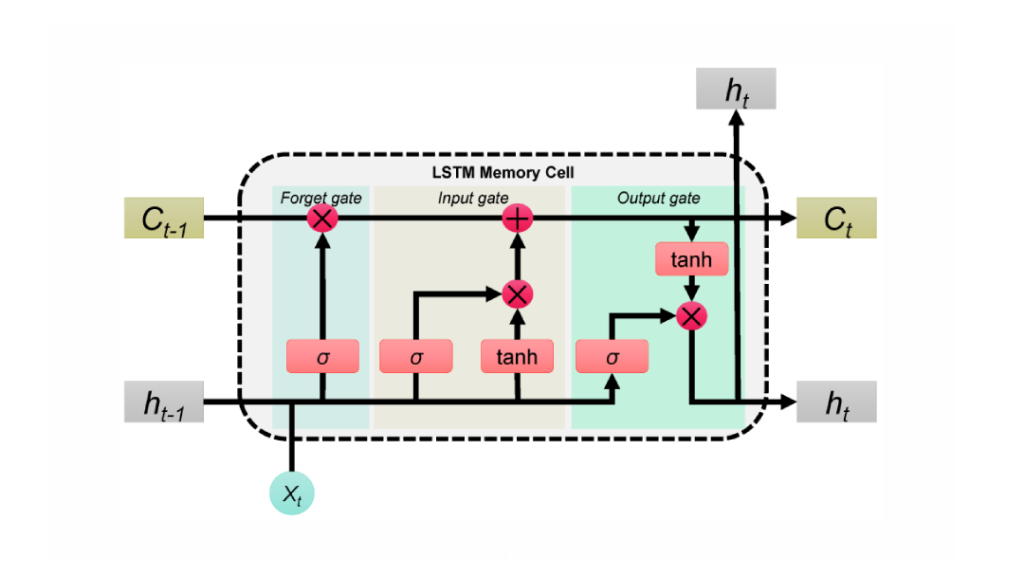

In [6]:
class LSTM_Layer(nn.Module):
    def __init__(self , input_dim):
        super().__init__()
        
        #LAYER 1
        # Forget Gate - How much of the current long term memory should be kept
        self.fb_input = nn.Linear(in_features=input_dim , out_features=64)
        self.fb_memory = nn.Linear(in_features=64 , out_features=64)

        # Input Gate - What is the new long term memory and how much of it do we have to remember
        self.ig_input_potmem = nn.Linear(in_features=input_dim , out_features=64)
        self.ig_memory_potmem = nn.Linear(in_features=64 , out_features=64)
        self.ig_input_perc = nn.Linear(in_features=input_dim , out_features=64)
        self.ig_memory_perc = nn.Linear(in_features=64 , out_features=64)

        # Output Gate - what should be the new short term memory seeing the current long term memory and current inputs
        self.og_input = nn.Linear(in_features=input_dim , out_features=64)
        self.og_memory = nn.Linear(in_features=64 , out_features=64)


    def forward(self , x , h , c):
        # h = hidden state (short term memory)
        # c = cell state (long term memory)

        # LAYER 1
        # forget gate
        fg = self.fb_input(x) + self.fb_memory(h)
        fg = torch.sigmoid(fg)
        c = c*fg

        # Input Gate
        ig_potmem = self.ig_input_potmem(x) + self.ig_memory_potmem(h)
        ig_potmem = torch.tanh(ig_potmem)
        ig_perc = self.ig_input_perc(x) + self.ig_memory_perc(h)
        ig_perc = torch.sigmoid(ig_perc)
        ig = ig_potmem * ig_perc
        c = c + ig

        # Output Gate
        og = self.og_input(x) + self.og_memory(h)
        og = torch.sigmoid(og)
        h = torch.tanh(c) * og

        return h,c
    


class LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.Layer1 = LSTM_Layer(14)
        self.Layer2 = LSTM_Layer(64)
        self.final = nn.Linear(in_features=128 , out_features=14)

    def forward(self , x):
        h1 = torch.zeros(len(x),64).to(device)
        c1 = torch.zeros(len(x),64).to(device)
        h2 = torch.zeros(len(x),64).to(device)
        c2 = torch.zeros(len(x),64).to(device)

        for i in range(x.shape[1]):
            h1,c1 = self.Layer1(x[:,i,:] , h1 , c1)
            h2,c2 = self.Layer2(h1 , h2 ,c2)
        y_pred = self.final(torch.cat((h1,h2),dim=1))
        return y_pred

In [7]:
len(loader)

6565

In [ ]:
torch.manual_seed(12)
Model = LSTM().to(device)
loss_fn = nn.MSELoss()
optimizer = Adam(Model.parameters() , lr=1e-2 , weight_decay=1e-1)

losses = []
_ = 0

for X,y in loader:
    _ += 1
    y_pred = Model(X)
    loss = loss_fn(y_pred,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if _ % 100 == 0:
        print(loss.item())

0.35636046528816223


In [ ]:
# badi values ko normalise bhi kar dena future mayank
# do layer ka banana                                     --DONE
# sirf temperature chahiye aur batch size ig 72*6 hoga 
# hidden layer ka size 32-256 hoga ig dekh lena ppt me   --DONE